<a href="https://colab.research.google.com/github/GilliardMorandim/mba-tcc-usp-inadimplencia/blob/eda%2Ffeature/pre_processing_balanceamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Requirements

In [1]:
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!pip install pyspark
!pip install mlxtend


In [2]:
import matplotlib.pyplot as plt
from google.colab import drive
import os
import pandas as pd

import numpy as np

# Import the required libraries for model training
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, confusion_matrix, recall_score, roc_auc_score, classification_report

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

drive.mount('/content/drive')

Mounted at /content/drive


# Lendo Arquivo Pyspark

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import col, when
from pyspark.sql.functions import try_divide

spark = (SparkSession.builder
         .appName("LoadAllCSVs")
         .config("spark.driver.memory", "8g")
         .config("spark.executor.memory", "8g")
         .config("spark.sql.files.maxPartitionBytes", "256m")
         .getOrCreate())

print("Spark iniciado!")

Spark iniciado!


In [4]:
dfs_spark = {}

base_path = "/content/drive/MyDrive/MBA - Ciencia de Dados - USP/dados_tcc/"

files = [f for f in os.listdir(base_path) if f.endswith(".csv")]

for file in files:
    full_path = os.path.join(base_path, file)
    print(f"\n📥 Lendo via PySpark: {file}")

    try:
        df = (spark.read
              .option("header", "true")
              .option("inferSchema", "true")
              .csv(full_path))

        key = file.replace(".csv", "")
        dfs_spark[key] = df

        print(f"✔ OK - Linhas (estimado pela Spark): {df.count()} | Colunas: {len(df.columns)}")

    except Exception as e:
        print(f"❌ Erro ao ler {file}: {e}")

print("\nTodos os arquivos foram processados!")

globals().update(dfs_spark)


📥 Lendo via PySpark: pre_aprovado.csv
✔ OK - Linhas (estimado pela Spark): 42171363 | Colunas: 11

📥 Lendo via PySpark: parcelas.csv
✔ OK - Linhas (estimado pela Spark): 1865444 | Colunas: 21

📥 Lendo via PySpark: contratos.csv
✔ OK - Linhas (estimado pela Spark): 382539 | Colunas: 26

📥 Lendo via PySpark: score_credito.csv
✔ OK - Linhas (estimado pela Spark): 266126 | Colunas: 3

📥 Lendo via PySpark: analise_conversao.csv
✔ OK - Linhas (estimado pela Spark): 538023 | Colunas: 12

📥 Lendo via PySpark: analise_conversao_v2.csv
✔ OK - Linhas (estimado pela Spark): 538023 | Colunas: 12

📥 Lendo via PySpark: analise_conversao_v3.csv
✔ OK - Linhas (estimado pela Spark): 533525 | Colunas: 11

📥 Lendo via PySpark: parcelas_main_pd_filtrado.csv
✔ OK - Linhas (estimado pela Spark): 1063816 | Colunas: 17

Todos os arquivos foram processados!


In [5]:
parcelas_main_pd_filtrado.show(5, truncate=False)

+--------------------------------------+--------------+---------------+--------------------------------------+--------------------------------------+--------------------------------------+---------------+----------------------------------------------------------------+--------------------------+--------------------------+-------+------------------------------+---------+------------+-----+----------------+--------------------------+
|id_contrato                           |data_pagamento|data_vencimento|id_parcela                            |uuid_cliente                          |id_contrato_original                  |id_contrato_pai|cpf_hash_sha256                                                 |flag_inadimplencia_90_days|flag_inadimplencia_30_days|valor  |valor_financiado_principal_iof|valor_iof|valor_tarifa|month|parcela_norm_0_1|valor_juros_remuneratorios|
+--------------------------------------+--------------+---------------+--------------------------------------+------------------

# EDA - Quantidade de contratos com 1 e 0 via Flag-Inadimplência 90 days

In [ ]:
contrato_inad_90 = (parcelas_main_pd_filtrado.groupBy("id_contrato").agg(F.max("flag_inadimplencia_90_days").alias("flag_inadimplencia_90_days")))

dist_classes = (
    contrato_inad_90
    .groupBy("flag_inadimplencia_90_days")
    .agg(
        F.countDistinct("id_contrato").alias("qtd_contratos")
    )
    .orderBy("flag_inadimplencia_90_days")
)

#distinção de classes - contando quantos contratos distintos estão em cada classe
total_contratos = (
    dist_classes
    .agg(F.sum("qtd_contratos").alias("total"))
    .collect()[0]["total"]
)

dist_classes_pct = (
    dist_classes
    .withColumn(
        "percentual_contratos",
        F.round(F.col("qtd_contratos") / F.lit(total_contratos) * 100, 2)
    )
)

dist_classes_pct.show()


#dist_classes.show()

+--------------------------+-------------+--------------------+
|flag_inadimplencia_90_days|qtd_contratos|percentual_contratos|
+--------------------------+-------------+--------------------+
|                         0|       295584|               89.86|
|                         1|        33354|               10.14|
+--------------------------+-------------+--------------------+



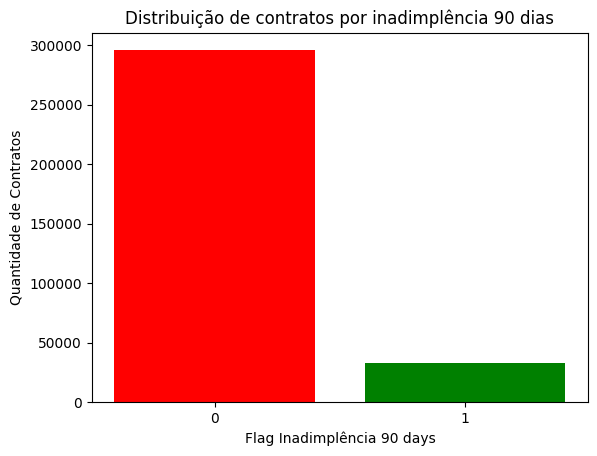

In [ ]:
pdf = dist_classes.toPandas()

plt.figure()
plt.bar(
    pdf["flag_inadimplencia_90_days"].astype(str),
    pdf["qtd_contratos"],
    color=["red", "green"]
)

plt.xlabel("Flag Inadimplência 90 days")
plt.ylabel("Quantidade de Contratos")
plt.title("Distribuição de contratos por inadimplência 90 dias")
plt.show()

# EDA - Quantidade de contratos com 1 e 0 via Flag-Inadimplência 30 days

In [ ]:
contrato_inad_30 = (parcelas_main_pd_filtrado.groupBy("id_contrato").agg(F.max("flag_inadimplencia_30_days").alias("flag_inadimplencia_30_days")))

dist_classes = (
    contrato_inad_30
    .groupBy("flag_inadimplencia_30_days")
    .agg(
        F.countDistinct("id_contrato").alias("qtd_contratos")
    )
    .orderBy("flag_inadimplencia_30_days")
)

#distinção de classes - contando quantos contratos distintos estão em cada classe
total_contratos = (
    dist_classes
    .agg(F.sum("qtd_contratos").alias("total"))
    .collect()[0]["total"]
)

dist_classes_pct = (
    dist_classes
    .withColumn(
        "percentual_contratos",
        F.round(F.col("qtd_contratos") / F.lit(total_contratos) * 100, 2)
    )
)

dist_classes_pct.show()

+--------------------------+-------------+--------------------+
|flag_inadimplencia_30_days|qtd_contratos|percentual_contratos|
+--------------------------+-------------+--------------------+
|                         0|       240080|               72.99|
|                         1|        88858|               27.01|
+--------------------------+-------------+--------------------+



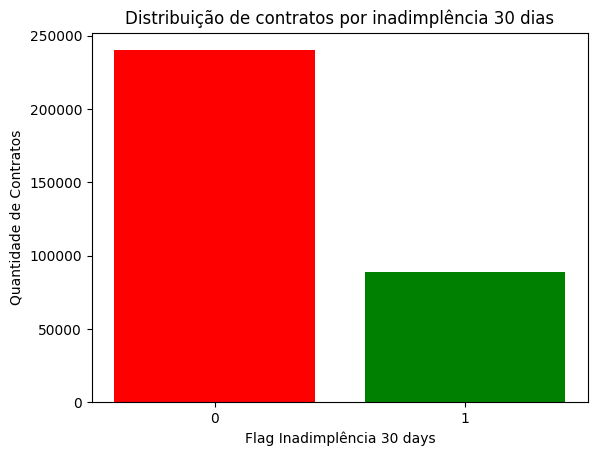

In [ ]:
pdf = dist_classes.toPandas()

plt.figure()
plt.bar(
    pdf["flag_inadimplencia_30_days"].astype(str),
    pdf["qtd_contratos"],
    color=["red", "green"]
)

plt.xlabel("Flag Inadimplência 30 days")
plt.ylabel("Quantidade de Contratos")
plt.title("Distribuição de contratos por inadimplência 30 dias")
plt.show()

# Separando Dados de Treino e Teste

In [6]:
def split_dataset(X, y, random_state=42):
    # treino / teste
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=random_state,
        stratify=y
    )

    return X_train, X_test, y_train, y_test

In [7]:
#flag_inadimplencia_90_days|flag_inadimplencia_30_days|valor  |valor_financiado_principal_iof|valor_iof|valor_tarifa|month|parcela_norm_0_1|valor_juros_remuneratorios|

df_aux = parcelas_main_pd_filtrado.toPandas()
y = df_aux["flag_inadimplencia_90_days"]
X = df_aux[["valor", "valor_financiado_principal_iof", "valor_iof", "valor_tarifa", "month", "parcela_norm_0_1", "valor_juros_remuneratorios"]]

# Train-Test Separation
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y) # mantém proporção das classes



# SMOTE

In [8]:
def pipeline_smote(X, y, random_state=42):
    X_train, X_test, y_train, y_test = split_dataset(X, y, random_state)

    pipeline = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=random_state, k_neighbors=5))
    ])

    X_train_res, y_train_res = pipeline.fit_resample(X_train, y_train)

    return X_train_res, X_test, y_train_res, y_test


In [9]:
# 90 dias
y_90 = df_aux["flag_inadimplencia_90_days"]
X = df_aux[["valor", "valor_financiado_principal_iof", "valor_iof", "valor_tarifa", "month", "parcela_norm_0_1", "valor_juros_remuneratorios"]]

Xtr_90, Xt_90, ytr_90, yt_90 = pipeline_smote(X, y_90)

# 30 dias
y_30 = df_aux["flag_inadimplencia_30_days"]
Xtr_30, Xt_30, ytr_30, yt_30 = pipeline_smote(X, y_30)


In [10]:
smote = SMOTE(
    sampling_strategy="auto",
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Distribuição original (treino):")
print(y_train.value_counts(normalize=True).round(4))

print("\nDistribuição após SMOTE (treino):")
print(y_train_smote.value_counts(normalize=True).round(4))

Distribuição original (treino):
flag_inadimplencia_90_days
0    0.9137
1    0.0863
Name: proportion, dtype: float64

Distribuição após SMOTE (treino):
flag_inadimplencia_90_days
0    0.5
1    0.5
Name: proportion, dtype: float64


In [11]:
print("Treino 90 dias (SMOTE):")
print(ytr_90.value_counts(normalize=True).round(3))

print("\nTreino 30 dias (SMOTE):")
print(ytr_30.value_counts(normalize=True).round(3))


Treino 90 dias (SMOTE):
flag_inadimplencia_90_days
0    0.5
1    0.5
Name: proportion, dtype: float64

Treino 30 dias (SMOTE):
flag_inadimplencia_30_days
0    0.5
1    0.5
Name: proportion, dtype: float64


- https://medium.com/data-and-beyond/exploring-pyspark-ml-for-machine-learning-handling-class-imbalances-part-2-2-f9113f6b40ba

- https://learn.microsoft.com/pt-br/fabric/data-science/tutorial-data-science-train-models

- https://datasciencehorizons.com/handling-imbalanced-datasets-in-scikit-learn-techniques-and-best-practices/

# Undersampling

In [12]:
def pipeline_undersampling(X, y, random_state=42):
    X_train, X_test, y_train, y_test = split_dataset(X, y, random_state)

    pipeline = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("undersample", RandomUnderSampler(random_state=random_state))
    ])

    X_train_res, y_train_res = pipeline.fit_resample(X_train, y_train)

    return X_train_res, X_test, y_train_res, y_test


In [13]:
# Target 30 dias
y_30 = df_aux["flag_inadimplencia_30_days"]

Xtr_30, Xt_30, ytr_30, yt_30 = pipeline_undersampling(X, y_30)

print("Treino 30 dias (Undersampling):")
print(ytr_30.value_counts(normalize=True).round(3))

Treino 30 dias (Undersampling):
flag_inadimplencia_30_days
0    0.5
1    0.5
Name: proportion, dtype: float64


In [18]:
# Target 90 dias
y_90 = df_aux["flag_inadimplencia_90_days"]

Xtr_90, Xt_90, ytr_90, yt_90 = pipeline_undersampling(X, y_90)

print("Treino 90 dias (Undersampling):")
print(ytr_90.value_counts(normalize=True).round(3))

Treino 90 dias (Undersampling):
flag_inadimplencia_90_days
0    0.5
1    0.5
Name: proportion, dtype: float64


# Oversampling

In [15]:
def pipeline_oversampling(X, y, random_state=42):
    X_train, X_test, y_train, y_test = split_dataset(X, y, random_state)

    pipeline = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("oversample", RandomOverSampler(random_state=random_state))
    ])

    X_train_res, y_train_res = pipeline.fit_resample(X_train, y_train)

    return X_train_res, X_test, y_train_res, y_test


In [19]:
# Target 30 dias
y_30 = df_aux["flag_inadimplencia_30_days"]

Xtr_30, Xt_30, ytr_30, yt_30 = pipeline_oversampling(X, y_30)

print("Treino 30 dias (Undersampling):")
print(ytr_30.value_counts(normalize=True).round(3))

Treino 30 dias (Undersampling):
flag_inadimplencia_30_days
0    0.5
1    0.5
Name: proportion, dtype: float64


In [17]:
# Target 90 dias
y_90 = df_aux["flag_inadimplencia_90_days"]

Xtr_90, Xt_90, ytr_90, yt_90 = pipeline_oversampling(X, y_90)

print("Treino 90 dias (Undersampling):")
print(ytr_90.value_counts(normalize=True).round(3))

Treino 90 dias (Undersampling):
flag_inadimplencia_90_days
0    0.5
1    0.5
Name: proportion, dtype: float64


# Pipeline

# Regressão Logistica

# Decision Tree

# Random Forest

# Naive Bayes

-  https://scikit-learn.org/stable/modules/naive_bayes.html
-  https://www.ibm.com/think/topics/naive-bayes
- https://www.datacamp.com/pt/tutorial/naive-bayes-scikit-learn

In [22]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

model.fit(X_train, y_train);

In [23]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    classification_report,
)

y_pred = model.predict(X_test)

accuray = accuracy_score(y_pred, y_test)
f1 = f1_score(y_pred, y_test, average="weighted")

print("Accuracy:", accuray)
print("F1 Score:", f1)

Accuracy: 0.49534695719200617
F1 Score: 0.40360538847994387
